In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

[]

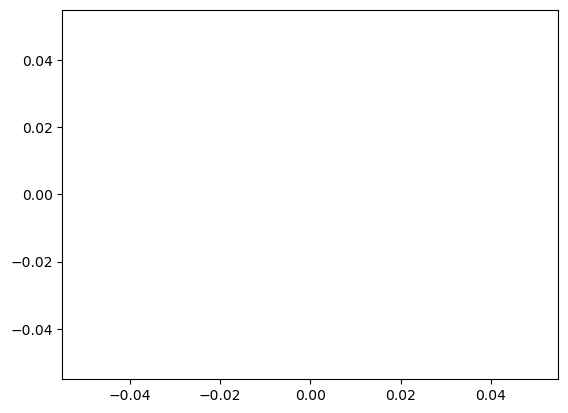

In [3]:
plt.plot()

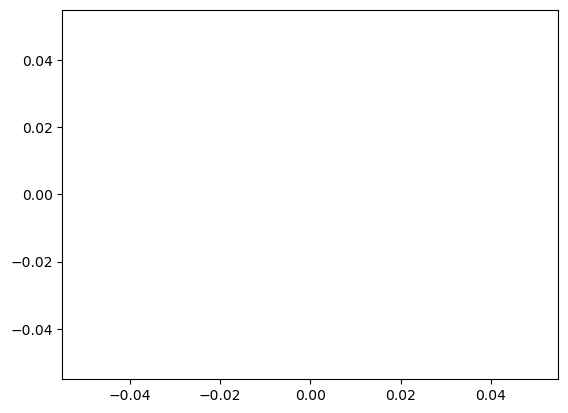

In [4]:
plt.plot();

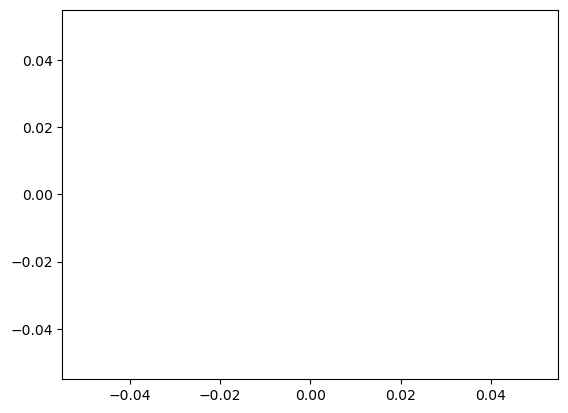

In [5]:
plt.plot()
plt.show()

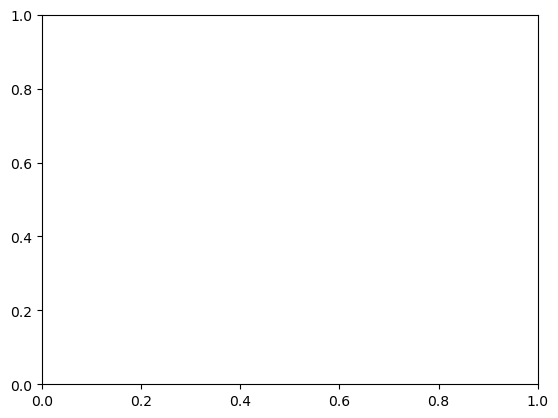

In [6]:
fig, ax = plt.subplots()

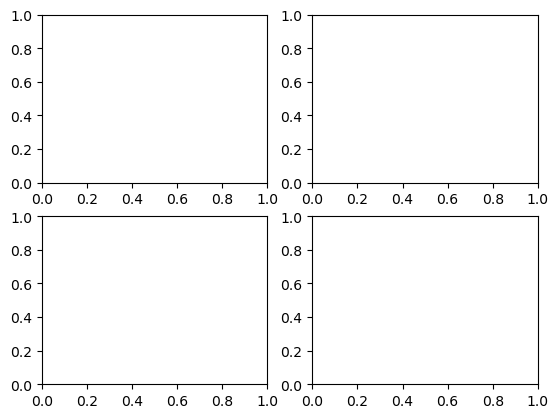

In [7]:
fig, ax = plt.subplots(nrows=2, ncols=2)

## numpy visualization

In [85]:
x = np.linspace(0, 10, 50)
state_names = ["AK", "AL", "AR", "AZ", "CA", "CO", "CT"]
car_sales_today = np.random.randint(10, size=(7,))

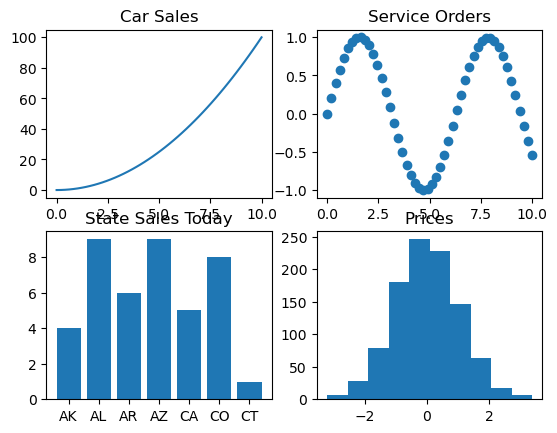

In [87]:
fig, ax = plt.subplots(nrows=2, ncols=2)
ax[0,0].plot(x, x**2)
ax[0,0].set_title("Car Sales")

ax[0,1].scatter(x, np.sin(x))
ax[0,1].set_title("Service Orders")

ax[1,0].bar(state_names, car_sales_today)
ax[1,0].set_title("State Sales Today")

ax[1,1].hist(np.random.randn(1000))
ax[1,1].set_title("Prices")

plt.show()

<BarContainer object of 7 artists>

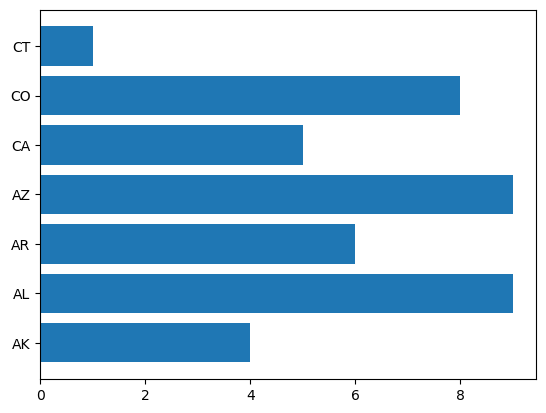

In [89]:
fig, ax = plt.subplots()
ax.barh(state_names, car_sales_today)

## Pandas Visualization

In [130]:
series = pd.Series(np.random.randn(20), index=pd.date_range("1/1/2025", periods=20))
series[:5]


2025-01-01    0.258282
2025-01-02    0.453489
2025-01-03   -1.429669
2025-01-04   -1.587094
2025-01-05   -0.341550
Freq: D, dtype: float64

In [131]:
series.cumsum()

2025-01-01    0.258282
2025-01-02    0.711771
2025-01-03   -0.717898
2025-01-04   -2.304991
2025-01-05   -2.646541
2025-01-06   -2.902810
2025-01-07   -3.988096
2025-01-08   -4.047389
2025-01-09   -3.789512
2025-01-10   -3.132382
2025-01-11   -4.351857
2025-01-12   -4.757682
2025-01-13   -3.380926
2025-01-14   -2.191537
2025-01-15   -1.946905
2025-01-16   -1.837550
2025-01-17   -1.865481
2025-01-18   -2.270011
2025-01-19   -1.997249
2025-01-20   -0.973241
Freq: D, dtype: float64

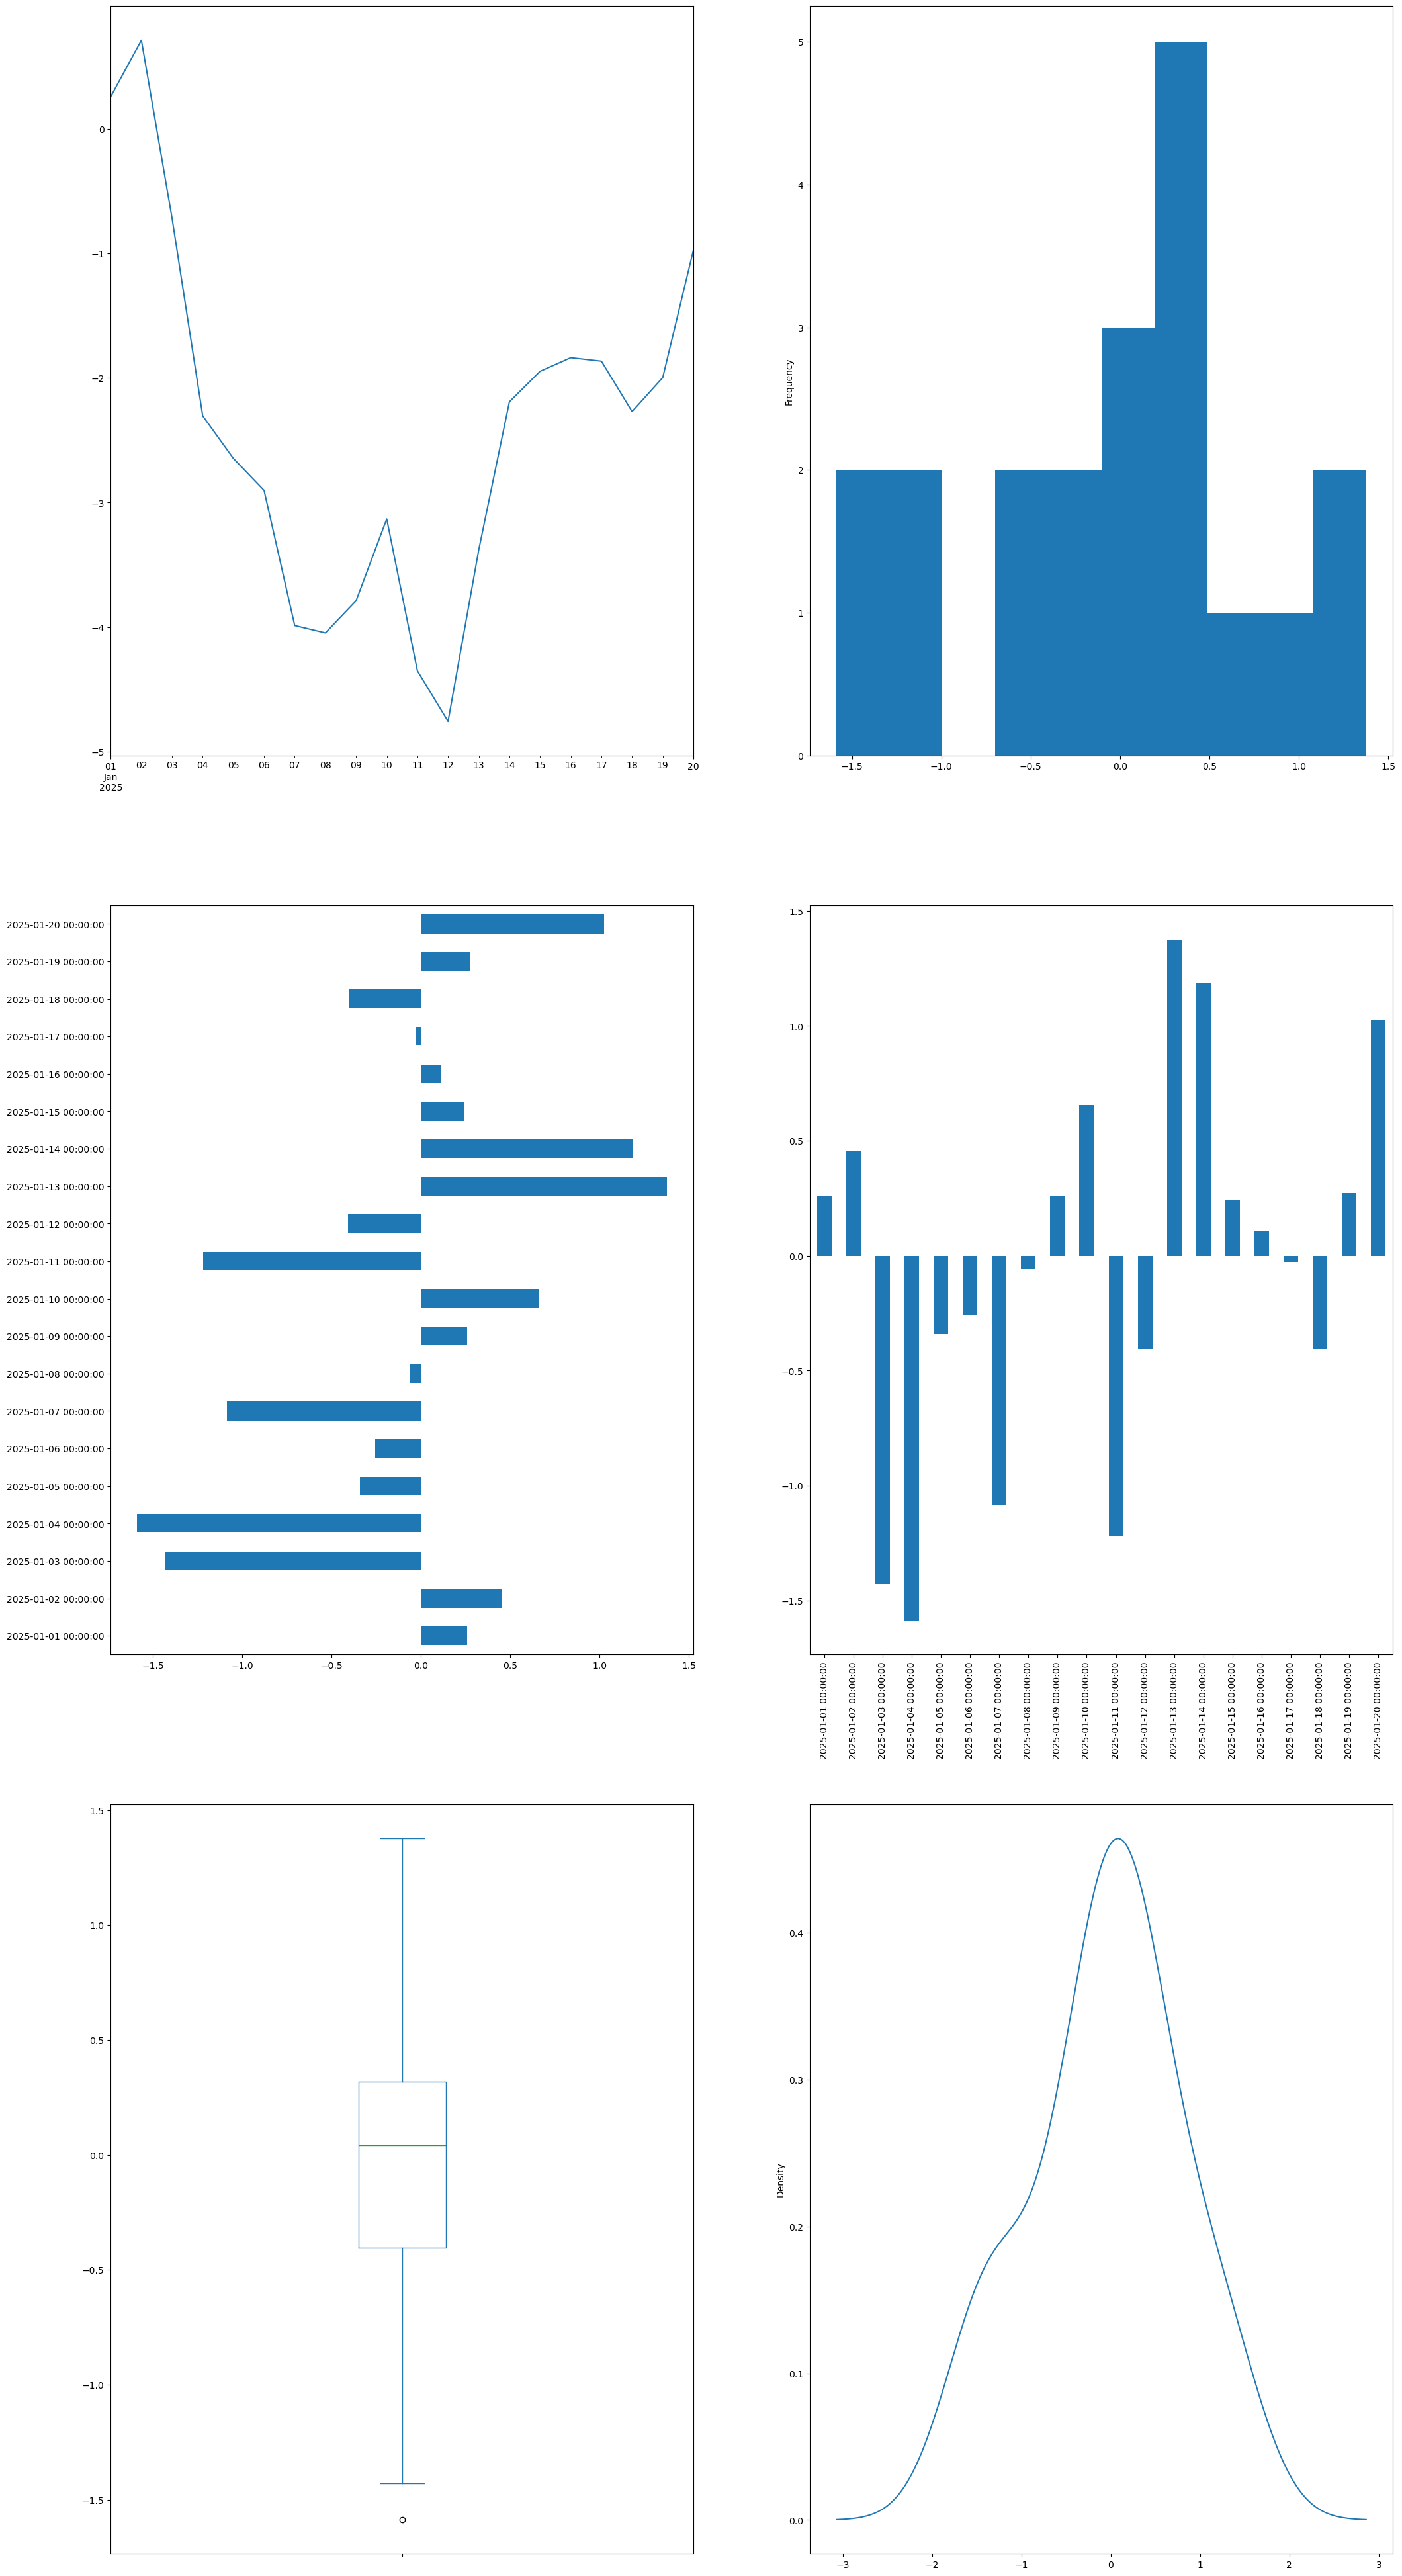

In [198]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(25,50))
series.cumsum().plot(ax=ax[0,0])
series.plot(ax=ax[0,1], kind="hist")
series.plot(ax=ax[1,0], kind="barh")
series.plot(ax=ax[1,1], kind="bar")
series.plot(ax=ax[2,0], kind="box")
series.plot(ax=ax[2,1], kind="density")
plt.show()

In [90]:
car_sales = pd.read_csv("data/car-sales.csv")
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,"$4,000.00"
1,Honda,Red,87899,4,"$5,000.00"
2,Toyota,Blue,32549,3,"$7,000.00"
3,BMW,Black,11179,5,"$22,000.00"
4,Nissan,White,213095,4,"$3,500.00"
5,Toyota,Green,99213,4,"$4,500.00"
6,Honda,Blue,45698,4,"$7,500.00"
7,Honda,Blue,54738,4,"$7,000.00"
8,Toyota,White,60000,4,"$6,250.00"
9,Nissan,White,31600,4,"$9,700.00"


In [91]:
car_sales["Price_bk"] = car_sales["Price"]

In [92]:
# convert Price from string to number


car_sales["Price"] = car_sales["Price_bk"].str.replace(r'[\$\,\.]', '', regex=True).astype(int) / 100

In [93]:
avg_price_by_make = car_sales.groupby('Make')['Price'].mean()

In [94]:
car_sales['Sale Date'] = pd.date_range('1/1/2025',periods=len(car_sales))
car_sales['Total Sales'] = np.cumsum(car_sales['Price'])
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Price_bk,Sale Date,Total Sales
0,Toyota,White,150043,4,4000.0,"$4,000.00",2025-01-01,4000.0
1,Honda,Red,87899,4,5000.0,"$5,000.00",2025-01-02,9000.0
2,Toyota,Blue,32549,3,7000.0,"$7,000.00",2025-01-03,16000.0
3,BMW,Black,11179,5,22000.0,"$22,000.00",2025-01-04,38000.0
4,Nissan,White,213095,4,3500.0,"$3,500.00",2025-01-05,41500.0
5,Toyota,Green,99213,4,4500.0,"$4,500.00",2025-01-06,46000.0
6,Honda,Blue,45698,4,7500.0,"$7,500.00",2025-01-07,53500.0
7,Honda,Blue,54738,4,7000.0,"$7,000.00",2025-01-08,60500.0
8,Toyota,White,60000,4,6250.0,"$6,250.00",2025-01-09,66750.0
9,Nissan,White,31600,4,9700.0,"$9,700.00",2025-01-10,76450.0


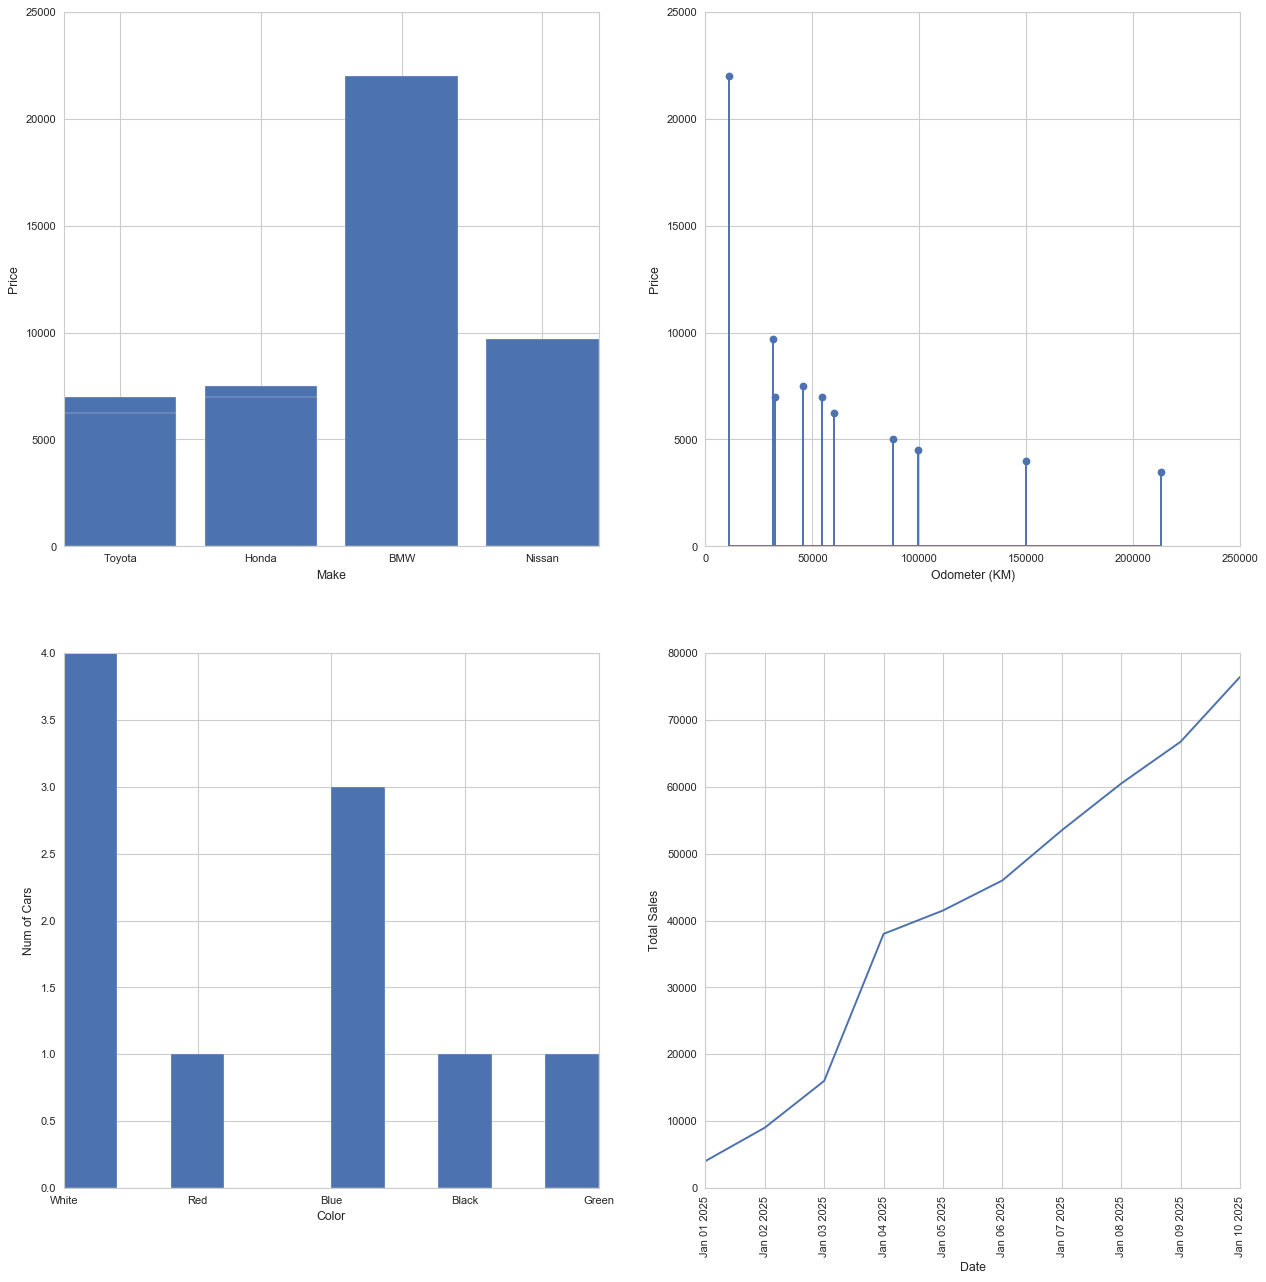

In [95]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15,15))


ax[0,0].bar(car_sales['Make'], car_sales['Price'])
ax[0,0].set_xlabel("Make")
ax[0,0].set_ylabel("Price")

ax[0,1].stem(car_sales['Odometer (KM)'], car_sales['Price'])
ax[0,1].set_xlabel("Odometer (KM)")
ax[0,1].set_ylabel("Price")

car_sales['Colour'].hist(ax=ax[1,0])
ax[1,0].set_xlabel("Color")
ax[1,0].set_ylabel("Num of Cars")



ax[1,1].plot(car_sales['Sale Date'], car_sales['Total Sales'])
ax[1,1].set_xlabel("Date")
ax[1,1].set_ylabel("Total Sales")
ax[1,1].tick_params(axis='x', rotation=90)



<Axes: xlabel='Sale Date'>

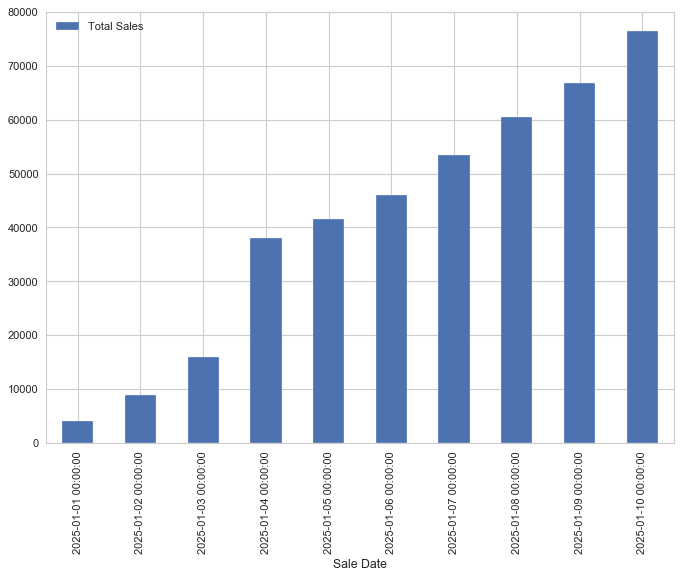

In [96]:
car_sales.plot(x='Sale Date', y='Total Sales',kind='bar')

### multi bar graph

In [97]:
x = np.random.rand(10,4)
x

array([[0.54718981, 0.77046804, 0.28572994, 0.08810509],
       [0.37871968, 0.02706036, 0.7688184 , 0.01568485],
       [0.43333299, 0.7868966 , 0.14434527, 0.60766868],
       [0.16505085, 0.13025939, 0.36883301, 0.65694905],
       [0.99593384, 0.37931396, 0.93653366, 0.59833049],
       [0.18201609, 0.61730844, 0.80287476, 0.28310322],
       [0.70990953, 0.33309491, 0.45175514, 0.80904239],
       [0.78197579, 0.35504736, 0.41868191, 0.1986838 ],
       [0.71476476, 0.45297067, 0.68359017, 0.58043148],
       [0.08506662, 0.33865126, 0.31595923, 0.70484955]])

In [98]:
df = pd.DataFrame(x)
df

,0,1,2,3
0,0.547190,0.770468,0.285730,0.088105
1,0.378720,0.027060,0.768818,0.015685
2,0.433333,0.786897,0.144345,0.607669
3,0.165051,0.130259,0.368833,0.656949
4,0.995934,0.379314,0.936534,0.598330
5,0.182016,0.617308,0.802875,0.283103
6,0.709910,0.333095,0.451755,0.809042
7,0.781976,0.355047,0.418682,0.198684
8,0.714765,0.452971,0.683590,0.580431
9,0.085067,0.338651,0.315959,0.704850


<Axes: >

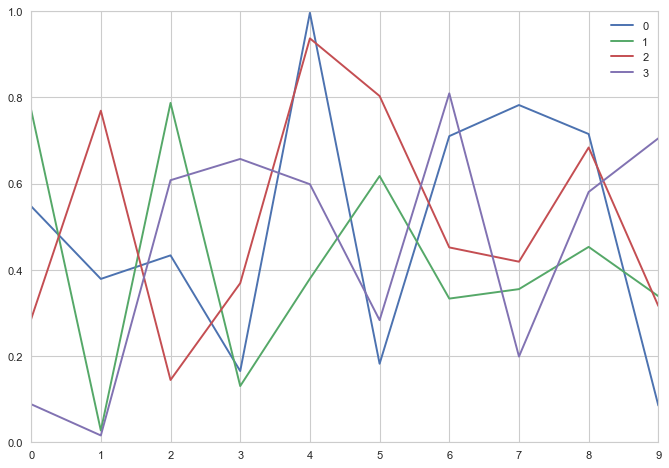

In [99]:
df.plot()

<Axes: >

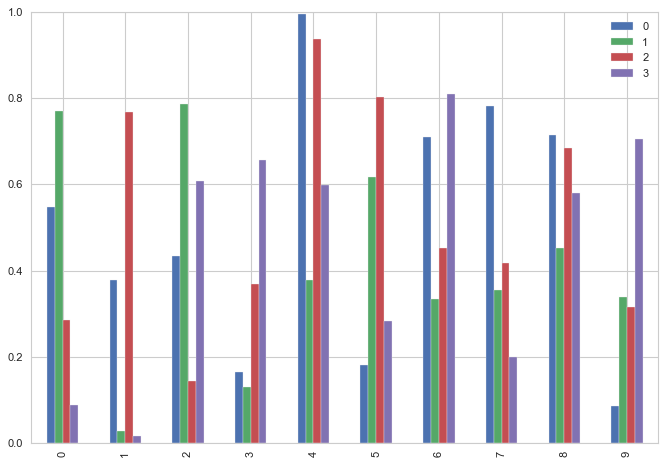

In [100]:
df.plot(kind='bar')

(<Axes: >, <Axes: >)

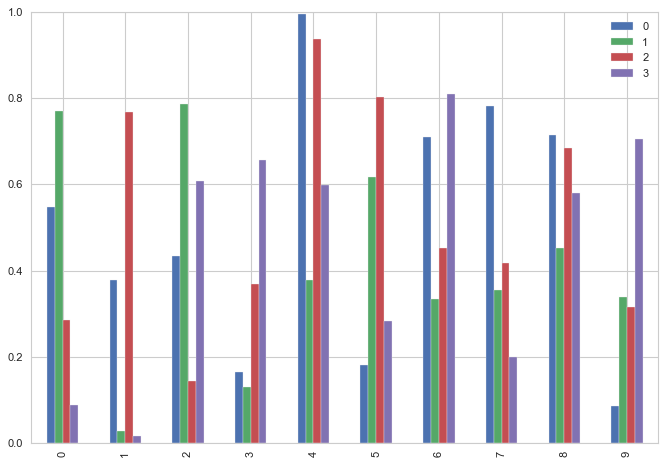

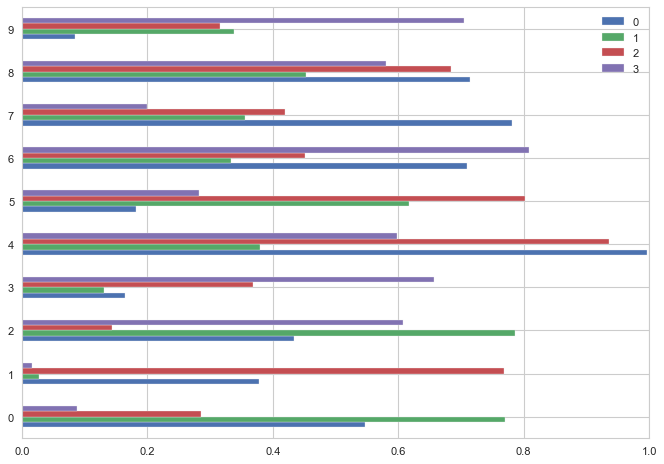

In [101]:
df.plot.bar(), df.plot.barh()

<Axes: ylabel='Frequency'>

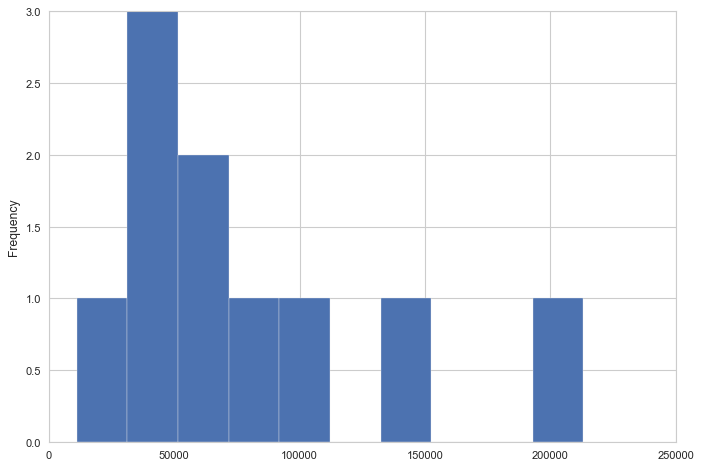

In [102]:
car_sales['Odometer (KM)'].plot.hist()

<Axes: ylabel='Frequency'>

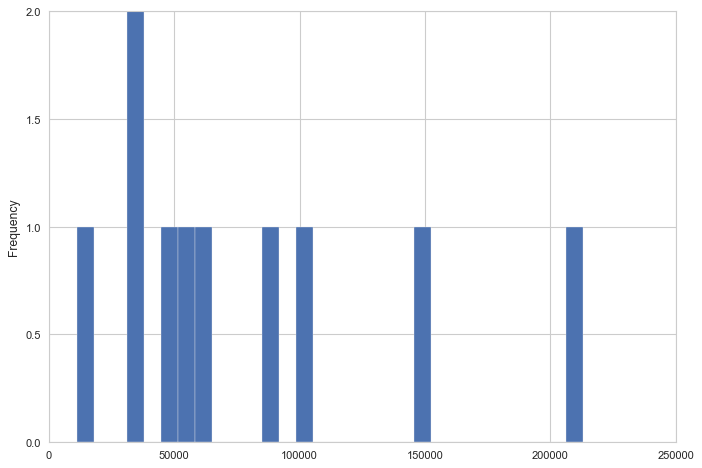

In [103]:
car_sales['Odometer (KM)'].plot.hist(bins=30)

## heart disease csv

In [104]:
%config IPCompleter.use_jedi = False

heart_disease = pd.read_csv('data/heart-disease.csv')
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


<Axes: ylabel='Frequency'>

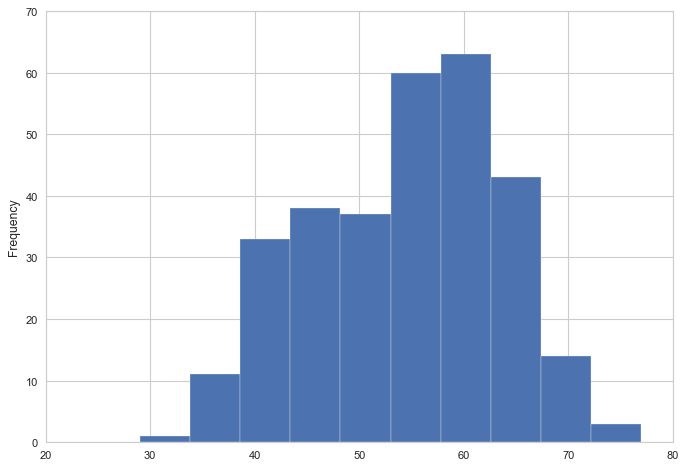

In [105]:
heart_disease['age'].plot.hist()

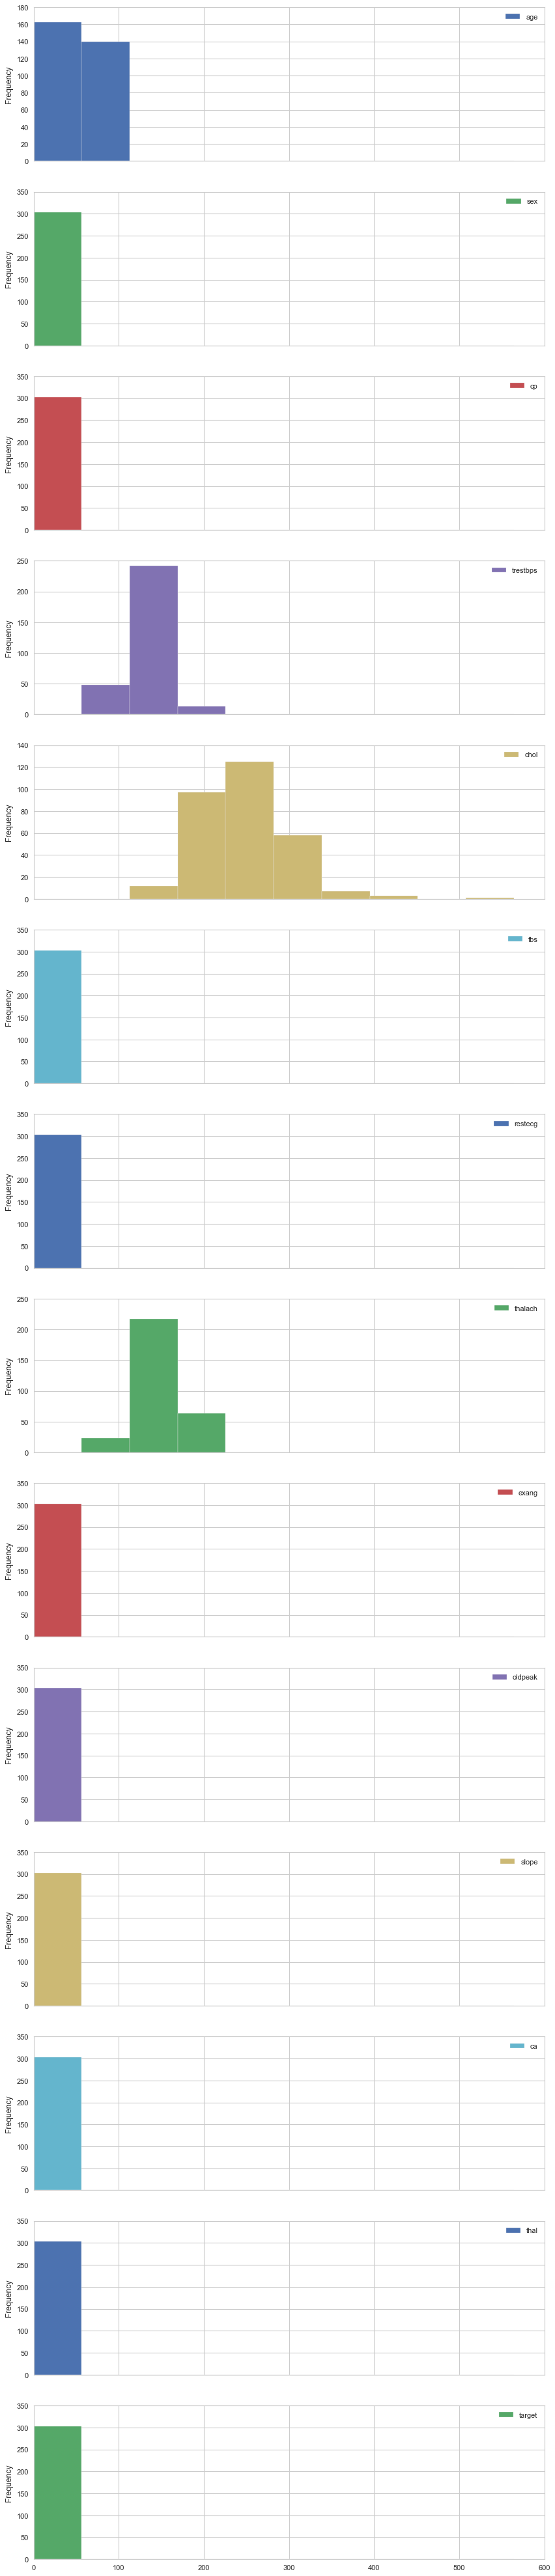

In [106]:
heart_disease.plot.hist(figsize=(10,50), subplots=True);

In [107]:
over_50 = heart_disease[heart_disease['age'] > 50]
over_50.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1


### Object Oriented plotting

Text(0.5, 0.98, 'Heart Disease Analysis')

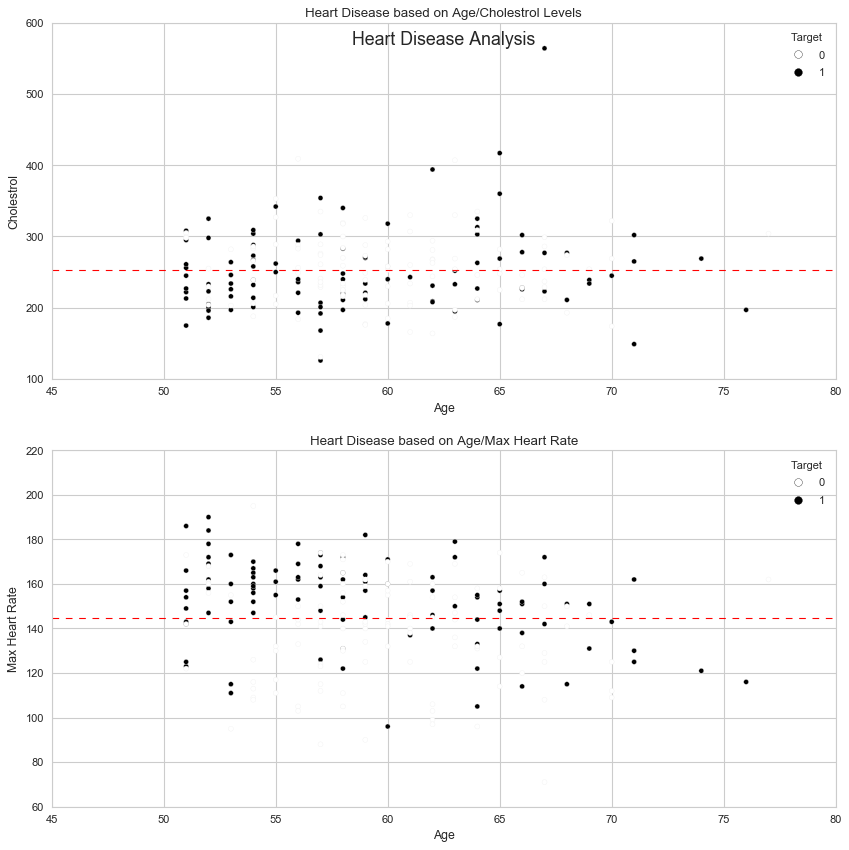

In [120]:
fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, figsize=(10,10))

sc0 = ax0.scatter(x=over_50['age'], y=over_50['chol'], c=over_50['target'])
ax0.set(title='Heart Disease based on Age/Cholestrol Levels', xlabel='Age', ylabel='Cholestrol')

handles, labels = sc0.legend_elements()

ax0.legend(handles=handles, labels=labels, title='Target')
# or
# ax0.legend(*scatter.legend_elements(), title='Target')
ax0.axhline(y=over_50['chol'].mean(), color='red', linestyle='--', linewidth=1)


# another subplot

sc1 = ax1.scatter(x=over_50['age'], y=over_50['thalach'], c=over_50['target'])
ax1.set(title='Heart Disease based on Age/Max Heart Rate', xlabel='Age', ylabel='Max Heart Rate')
ax1.legend(*sc1.legend_elements(), title='Target')
ax1.axhline(y=over_50['thalach'].mean(), color='red', linestyle='--', linewidth=1)

fig.suptitle(t='Heart Disease Analysis',fontsize=16)


### customizations

In [109]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

[Text(0.5, 1.0, 'Car Sales')]

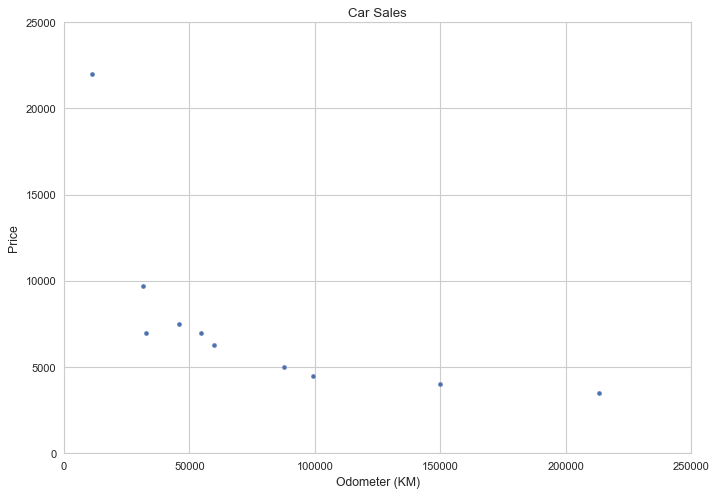

In [115]:
plt.style.use('seaborn-v0_8-whitegrid')
ax = car_sales.plot(x='Odometer (KM)', y='Price', kind='scatter');
ax.set(title='Car Sales',)

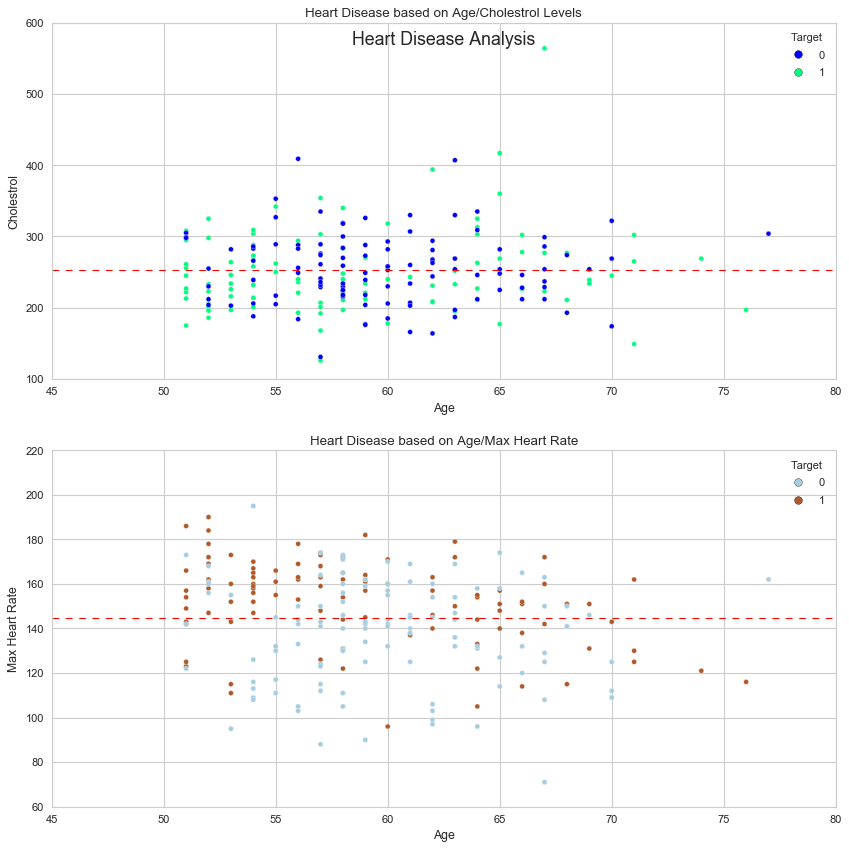

In [129]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, figsize=(10,10))

sc0 = ax0.scatter(x=over_50['age'], y=over_50['chol'], c=over_50['target'], cmap='winter')
ax0.set(title='Heart Disease based on Age/Cholestrol Levels', xlabel='Age', ylabel='Cholestrol')

handles, labels = sc0.legend_elements()

ax0.legend(handles=handles, labels=labels, title='Target')
# or
# ax0.legend(*scatter.legend_elements(), title='Target')
ax0.axhline(y=over_50['chol'].mean(), color='red', linestyle='--', linewidth=1)


# another subplot

sc1 = ax1.scatter(x=over_50['age'], y=over_50['thalach'], c=over_50['target'], cmap='Paired')
ax1.set(title='Heart Disease based on Age/Max Heart Rate', xlabel='Age', ylabel='Max Heart Rate')
ax1.legend(*sc1.legend_elements(), title='Target')
ax1.axhline(y=over_50['thalach'].mean(), color='red', linestyle='--', linewidth=1)

fig.suptitle(t='Heart Disease Analysis',fontsize=16);


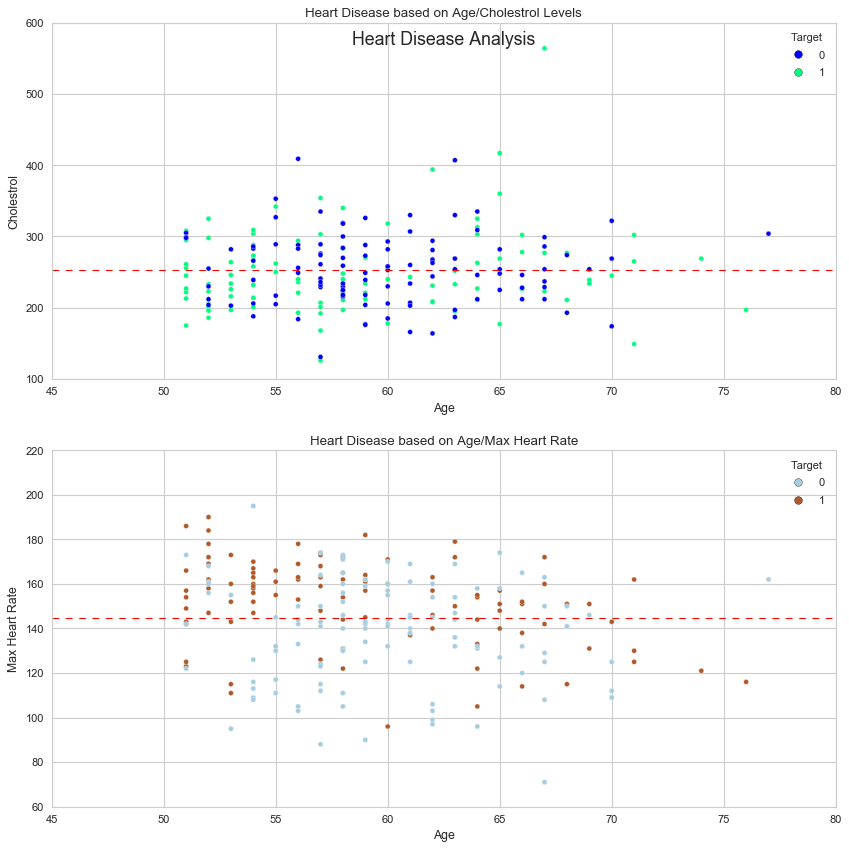

In [130]:
fig

In [131]:
fig.savefig("images/heart_disease_analysis_plot.png")